## Monitoring

In [28]:
import pandas as pd
import numpy as np
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, recall_score, auc, average_precision_score, precision_recall_curve, roc_curve, brier_score_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import joblib
import sys
from pathlib import Path
import shap
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm

PARENT_DIRECTORY_1 = Path.cwd().parent.parent.parent
sys.path.append(f"{str(PARENT_DIRECTORY_1)}")

from Feature_Engineering.utils.selection.psi import dataframe_psi
from Feature_Engineering.utils.transformers.outliers import AutoOutlierHandler
from Feature_Engineering.utils.transformers.binning import Binning
from Training_Model.utils.metrics import calibration_curve

In [2]:
## Evolutivo missing de variables
## Outliers univariados por regla IQR usando cortes del train
## PSI
## PSI por segmento (alguno importante)
## bad rate por deciles definidos en el Train
## GINI performance
## PR CURVE
## Prevalencia (PD vs RD)
## Variación en contribución de SHAP
## Calibración
## IV drift



In [3]:
PATH = '../data/external/'
df_test = pd.read_csv(f'{PATH}df_oot.csv', parse_dates= ['fecha_observacion'])
df_val_economico = pd.read_csv('../data/external/df_val_enriquecido.csv', index_col= 0)
df_train = pd.read_csv(f'../data/raw/cs-training.csv', index_col= 0)

TARGET = 'SeriousDlqin2yrs'

DICT_MESES = {
    '01': 'Ene',
    '02': 'Feb',
    '03': 'Mar',
    '04': 'Abr',
    '05': 'May',
    '06': 'Jun',
    '07': 'Jul',
    '08': 'Ago',
    '09': 'Sep',
    '10': 'Oct',
    '11': 'Nov',
    '12': 'Dic'
}
FEATS_NUMERICAS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]
PERIODO= 'fecha_observacion'

In [4]:
df_test['fecha_observacion'] = df_test['fecha_observacion'].dt.to_period('M')
df_test.head(5)

,fecha_observacion,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,saldo_actual,clasificacion_sbs,Garantia,y_score_modelo,SeriousDlqin2yrs
0,2025-07,0.221643,64,0,0.219751,25000.0,11,0,1,0,0.0,58235.03,Normal,35425.37,0.012255,0
1,2025-07,0.360597,59,0,0.705925,2750.0,5,0,1,0,2.0,7149.74,Normal,5456.82,0.024858,0
2,2025-07,0.444956,27,2,1450.000000,NaN,13,0,0,0,0.0,16768.38,CPP,0.00,0.185466,0
3,2025-07,0.407392,51,0,0.165647,6700.0,8,0,0,0,0.0,37233.08,Normal,0.00,0.029234,0
4,2025-07,0.442624,60,0,0.359637,3750.0,11,0,0,0,0.0,15625.59,Normal,0.00,0.034235,0


In [5]:
df_test['fecha_observacion_str'] = (
    df_test["fecha_observacion"].astype(str).str[5:7].map(DICT_MESES) + "'" +
    df_test["fecha_observacion"].astype(str).str[2:4]
)
df_test

,fecha_observacion,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,saldo_actual,clasificacion_sbs,Garantia,y_score_modelo,SeriousDlqin2yrs,fecha_observacion_str
0,2025-07,0.221643,64,0,0.219751,25000.0,11,0,1,0,0.0,58235.03,Normal,35425.37,0.012255,0,Jul'25
1,2025-07,0.360597,59,0,0.705925,2750.0,5,0,1,0,2.0,7149.74,Normal,5456.82,0.024858,0,Jul'25
2,2025-07,0.444956,27,2,1450.000000,NaN,13,0,0,0,0.0,16768.38,CPP,0.00,0.185466,0,Jul'25
3,2025-07,0.407392,51,0,0.165647,6700.0,8,0,0,0,0.0,37233.08,Normal,0.00,0.029234,0,Jul'25
4,2025-07,0.442624,60,0,0.359637,3750.0,11,0,0,0,0.0,15625.59,Normal,0.00,0.034235,0,Jul'25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101498,2026-06,0.143886,40,0,0.268748,7333.0,6,0,1,0,2.0,25162.17,Normal,24871.76,0.015387,0,Jun'26
101499,2026-06,0.003933,80,0,410.000000,NaN,2,0,1,0,0.0,12057.50,Normal,11952.90,0.008559,0,Jun'26
101500,2026-06,0.017731,64,0,0.005319,10339.0,14,0,0,0,0.0,11893.18,Normal,0.00,0.010509,0,Jun'26
101501,2026-06,0.092092,51,0,0.494942,4250.0,12,0,2,0,0.0,25526.99,Normal,17493.10,0.017030,0,Jun'26


Performance Seguimiento (Gini, AUC)

In [6]:
model_catboost = joblib.load('../artifacts/training_model/model_catboost_extra.pkl')

In [7]:
pred_proba_val = model_catboost.predict_proba(df_val_economico[FEATS_NUMERICAS])[:,1]
pred_proba_test = model_catboost.predict_proba(df_test[FEATS_NUMERICAS])[:,1]
pred_proba_train = model_catboost.predict_proba(df_train[FEATS_NUMERICAS])[:,1]

In [7]:
def monitor_performance_fix_baseline(pipeline_model, expected_x, actual_x, expected_y, actual_y, col_period, show_graph= False):
    expected_x = expected_x.copy()
    actual_x = actual_x.copy()
    #period_expected = sorted(expected[col_period].unique())
    period_actual = sorted(actual_x[col_period].unique())
    list_performance = []
    proba_expected = pipeline_model.predict_proba(expected_x)[:,1]
    #print(proba_expected.shape)
    #print(proba_expected)
    roc_expected = roc_auc_score(y_true= expected_y, y_score= proba_expected)
    gini_expected = 2 * roc_expected - 1
    list_performance.append({
        'Periodo': 'Expected Global',
        'AUC': round(roc_expected, 2),
        'Gini': round(gini_expected, 2)
    })
    feats_actual = [col for col in actual_x.columns.tolist() if col != col_period]
    proba_actual_global = pipeline_model.predict_proba(actual_x[feats_actual])[:,1]
    roc_actual_global = roc_auc_score(y_true= actual_y, y_score= proba_actual_global)
    gini_actual_global = 2 * roc_actual_global - 1
    list_performance.append({
        'Periodo': 'Actual Global',
        'AUC': round(roc_actual_global, 2),
        'Gini': round(gini_actual_global, 2)
    })
    for period in period_actual:
        mask = (actual_x[col_period] == period)
        #df_period = actual.loc[actual[col_period] == period]
        proba_actual = pipeline_model.predict_proba(actual_x[feats_actual][mask])[:,1]
        roc_score = roc_auc_score(y_true= actual_y[mask], y_score= proba_actual)
        gini = 2 * roc_score - 1
        list_performance.append({
            'Periodo': f'Actual: {period}',
            'AUC': round(roc_score, 2),
            'Gini': round(gini, 2)
        })

    df_monitor_performance = pd.DataFrame(list_performance)

    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 5))
        ax.plot(
            df_monitor_performance['Periodo'],
            df_monitor_performance['AUC'],
            color = 'gray',
            label = 'AUC',
            marker = 'o'
        )
        ax.set_title('Monitoreo AUC', y= 1.02)
        ax.set_xlabel('Periodos', fontsize = 7)
        ax.tick_params(axis= 'x', rotation = 45)
        ax.set_ylabel('AUC')
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )
        ax2 = ax.twinx()
        ax2.plot(
            df_monitor_performance['Periodo'],
            df_monitor_performance['Gini'],
            color = 'tomato',
            label = 'Gini',
            marker = 'o'
        )
        ax2.set_ylabel('Monitoreo Gini')
        ax2.set_ylim(0, 1)
        ax2.yaxis.set_major_formatter(
            PercentFormatter(1)
        )
        object_plot_1, legend_1 = ax.get_legend_handles_labels()
        object_plot_2, legend_2 = ax2.get_legend_handles_labels()
        ax.legend(object_plot_1 + object_plot_2,
                   legend_1 + legend_2,
                   loc= 'lower right')
        plt.tight_layout()
        plt.close(fig)
        return df_monitor_performance, fig
    return df_monitor_performance



,Periodo,AUC,Gini
0,Expected Global,0.87,0.73
1,Actual Global,0.84,0.69
2,Actual: 2025-07,0.85,0.70
3,Actual: 2025-08,0.85,0.70
4,Actual: 2025-09,0.85,0.69
5,Actual: 2025-10,0.84,0.68
6,Actual: 2025-11,0.85,0.69
7,Actual: 2025-12,0.84,0.67
8,Actual: 2026-01,0.84,0.67
9,Actual: 2026-02,0.85,0.70


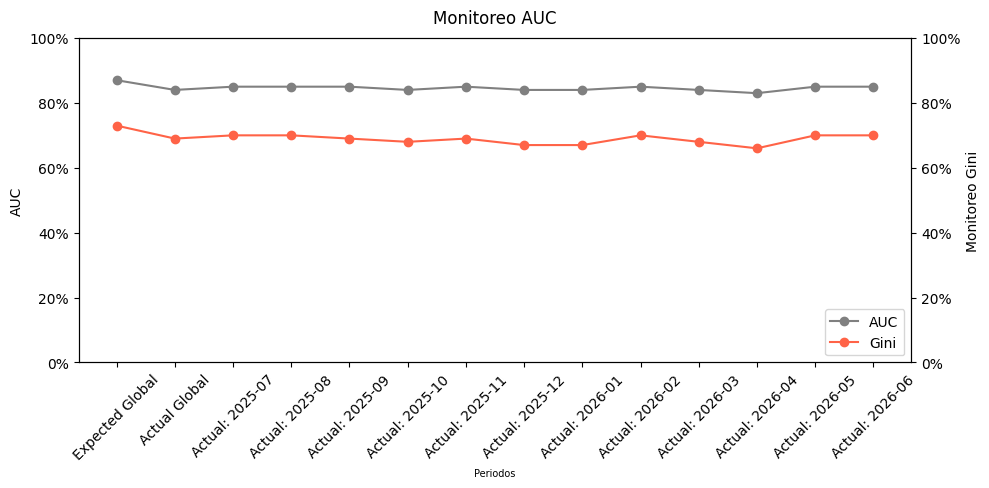

In [8]:
df_monitor_performance, fig = monitor_performance_fix_baseline(
    pipeline_model= model_catboost,
    expected_x= df_val_economico[FEATS_NUMERICAS],
    expected_y= df_val_economico[TARGET],
    actual_x= df_test[FEATS_NUMERICAS + [PERIODO]],
    actual_y= df_test[TARGET],
    col_period= 'fecha_observacion',
    show_graph= True
)
display(df_monitor_performance)
fig

In [9]:
fechas_resumen = (
    df_test.groupby('fecha_observacion')[FEATS_NUMERICAS]
    .apply(lambda x: x.isna().mean())
    .reset_index()
    .melt(id_vars= 'fecha_observacion', var_name= 'feature', value_name= 'missing_rate')
)
fechas_resumen

,fecha_observacion,feature,missing_rate
0,2025-07,RevolvingUtilizationOfUnsecuredLines,0.000000
1,2025-08,RevolvingUtilizationOfUnsecuredLines,0.000000
2,2025-09,RevolvingUtilizationOfUnsecuredLines,0.000000
3,2025-10,RevolvingUtilizationOfUnsecuredLines,0.000000
4,2025-11,RevolvingUtilizationOfUnsecuredLines,0.000000
...,...,...,...
115,2026-02,NumberOfDependents,0.023692
116,2026-03,NumberOfDependents,0.025283
117,2026-04,NumberOfDependents,0.025629
118,2026-05,NumberOfDependents,0.026733


In [10]:
def monitor_missing(X: pd.DataFrame, period_name, dict_period = None):
    X = X.copy()
    feats_x = [col for col in X.columns.tolist() if col != period_name]
    agg = (
    X.groupby(period_name)[feats_x]
    .apply(lambda x: x.isna().mean())
    .reset_index()
    .melt(id_vars= period_name, var_name= 'feature', value_name= 'missing_rate')
    ).sort_values(by= period_name, ascending = True) 

    if dict_period is not None:
        agg[f'{period_name}_transform'] = agg[period_name].astype(str).str[-2:].map(dict_period) + "'" +agg[period_name].astype(str).str[2:4]

    feats = (
        agg.loc[agg['missing_rate'].gt(0), 'feature']
        .unique().tolist()
    )
    #feats = sorted(feats)
    fig, ax = plt.subplots(1, 1 , figsize = (10,5))
    for feat in feats:
        if dict_period is not None:
            eje_x = agg.loc[agg['feature'] == feat, f'{period_name}_transform']
        else:
            eje_x = agg.loc[agg['feature'] == feat, period_name]
        #print(eje_x)
        ax.plot(
            eje_x,
            agg.loc[agg['feature'] == feat, 'missing_rate'],
            marker = 'o',
            label = feat
        )
        ax.set_ylim(0, 1)
        ax.legend()
        ax.set_xlabel('Periodo')
        ax.set_ylabel('Porcentaje de Missings')
        ax.set_title('Evolutivo de Porcentaje de Missing por Feature', y = 1.02)
        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )
        
    plt.tight_layout()
    plt.close(fig)
    return fig

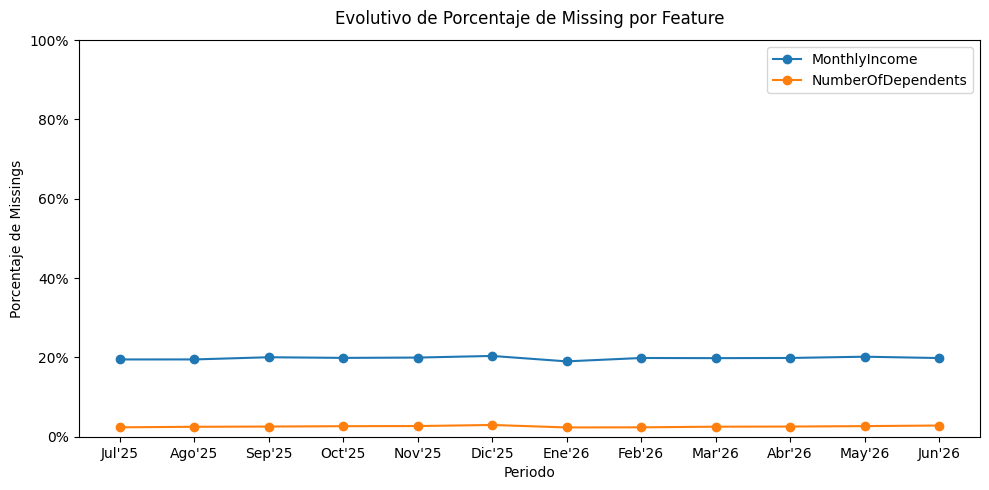

In [11]:
fig_missing = monitor_missing(X= df_test[(FEATS_NUMERICAS + [PERIODO])], period_name= 'fecha_observacion', dict_period = DICT_MESES)
fig_missing

PSI

In [12]:
a = pd.Series([3, 2,1])
a[0]

3

In [78]:
def monitoring_psi_baseline_fix(expected, actual, period_col, show_graph, dict_transform = None):

    periods_actual = sorted(actual[period_col].unique())
    periodos_lista = []
    for period in periods_actual:
        lista_period_tmp = dataframe_psi(
            train_df= expected,
            test_df= actual,
            period_name= period,
            return_dict= True
        )
        periodos_lista.extend(lista_period_tmp)

    df_psi = pd.DataFrame(periodos_lista)
    feats_psi = df_psi['feature'].unique().tolist()

    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 7))
        #print(feats_psi)
        for feat in feats_psi:
            feat_df = df_psi.loc[df_psi['feature'] == feat]
            if dict_transform is not None:
                period_str = feat_df['period'].astype(str).str[-2:].map(dict_transform) + "'" + feat_df['period'].astype(str).str[2:4]
            else:
                period_str = feat_df['period'].astype(str)
            ax.plot(
                period_str,
                feat_df['psi'],
                label = feat,
                marker = 'o'
            )
        ax.axhline(y =0.25, linestyle = '--', color= 'tomato')
        ax.text(
            0.5, 0.10, 'Estabilidad',
            transform=ax.get_yaxis_transform(),
            ha='center',
            va='bottom'
        )   
        ax.axhline(y=0.10, linestyle='--', color = 'green')
        ax.text(
            0.5, 0.25, 'Alerta',
            transform=ax.get_yaxis_transform(),
            ha='center',
            va='bottom'
        )
        ax.set_title('Monitoreo PSI por cada Feature', y= 1.02)
        ax.set_xlabel('Periodos', fontsize = 9)
        ax.tick_params(axis= 'x', rotation = 45)
        ax.set_ylabel('PSI')
        ax.set_ylim(0, max((feat_df['psi'].max()+0.001), 0.5))
        #ax.yaxis.set_major_formatter(
        #    PercentFormatter(1)
        #)
        ax.legend()
        plt.tight_layout()
        plt.close(fig)
        return df_psi, fig
        
    return df_psi



,feature,type,psi,interpretacion,period
0,RevolvingUtilizationOfUnsecuredLines,numeric,0.0001,Sin drift,2025-07
1,age,numeric,0.0001,Sin drift,2025-07
2,NumberOfTime30-59DaysPastDueNotWorse,numeric,0.0000,Sin drift,2025-07
3,DebtRatio,numeric,0.0001,Sin drift,2025-07
4,MonthlyIncome,numeric,0.0004,Sin drift,2025-07
...,...,...,...,...,...
115,NumberOfOpenCreditLinesAndLoans,numeric,0.0001,Sin drift,2026-06
116,NumberOfTimes90DaysLate,numeric,0.0000,Sin drift,2026-06
117,NumberRealEstateLoansOrLines,numeric,0.0001,Sin drift,2026-06
118,NumberOfTime60-89DaysPastDueNotWorse,numeric,0.0000,Sin drift,2026-06


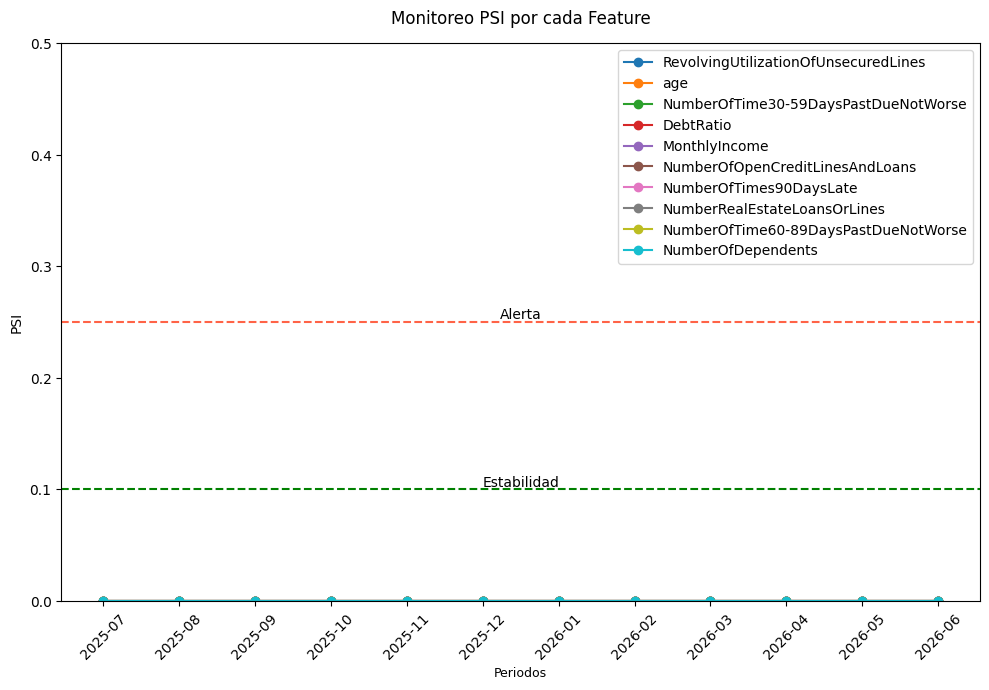

In [79]:
df_psi, fig = monitoring_psi_baseline_fix(
    expected= df_train[FEATS_NUMERICAS],
    actual = df_test,
    period_col= 'fecha_observacion',
    show_graph= True,
    dict_transform = None
)
display(df_psi)
fig

Outliers univariados por regla IQR usando cortes del train

In [128]:
def monitoring_outliers_univariado(expected, actual, period_col, show_graph = False, dict_transform = None):
    objeto_iqr = AutoOutlierHandler(
        exclude_continuous= False,
        method= 'iqr',
        strategy='windsorize',
        return_dataframe= True
    )
    objeto_iqr.fit(X= expected)
    dict_rules = objeto_iqr.resultados_
    feats_train = [col for col in dict_rules.keys()]
    periods_actual = sorted(actual[period_col].unique())
    expected_outliers_n_map = {}
    expected_outliers_var_map = {}

    for feat in feats_train:
        min_value = dict_rules[feat]['lower_limit']
        max_value = dict_rules[feat]['upper_limit']
        outliers_iqr_expected_var = ( ( (expected[feat]< min_value) | (expected[feat]> max_value) ).sum() ) / expected[feat].count()
        outliers_iqr_expected_n = ( ( (expected[feat]< min_value) | (expected[feat]> max_value) ).sum() )
        expected_outliers_n_map[feat] = outliers_iqr_expected_n
        expected_outliers_var_map[feat] = outliers_iqr_expected_var
        
    lista_outliers = []
    for period in periods_actual:
        for feat in feats_train:
            actual_interval = actual.loc[actual[period_col] == period]
            min_value = dict_rules[feat]['lower_limit']
            max_value = dict_rules[feat]['upper_limit']
            outliers_iqr_var =  ( ((actual_interval[feat]< min_value) | (actual_interval[feat]> max_value) ).sum() ) / actual_interval[feat].count()
            outliers_iqr_n =  ( ((actual_interval[feat]< min_value) | (actual_interval[feat]> max_value) ).sum() ) 
            lista_outliers.append({
                'period': period,
                'feature': feat,
                'cantidad_outliers_iqr': outliers_iqr_n,
                'var_outliers_iqr': outliers_iqr_var
            })
    df_outliers = pd.DataFrame(lista_outliers)
    df_outliers['cantidad_out_iqr_expected'] = df_outliers['feature'].map(expected_outliers_n_map)
    df_outliers['variacion_out_iqr_expected'] = df_outliers['feature'].map(expected_outliers_var_map)
    df_outliers['variacion_iqr_final'] = (df_outliers['var_outliers_iqr'] - df_outliers['variacion_out_iqr_expected']).abs()

    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 7))
        
        for feat in feats_train:
            feat_df = df_outliers.loc[df_outliers['feature'] == feat]
            if dict_transform is not None:
                period_str = feat_df['period'].astype(str).str[-2:].map(dict_transform) + "'" + feat_df['period'].astype(str).str[2:4]
            else:
                period_str = feat_df['period'].astype(str)
            ax.plot(
                period_str,
                feat_df['variacion_iqr_final'],
                label = feat,
                marker = 'o'
            )
        ax.set_title('Monitoreo Outliers IQR por cada Feature', y= 1.02)
        ax.set_xlabel('Periodos', fontsize = 9)
        ax.tick_params(axis= 'x', rotation = 45)
        ax.set_ylabel('Variación % Outliers IQR')
        ax.set_ylim(0, (df_outliers['variacion_iqr_final'].max()+0.03))
        #print(feat_df['variacion_iqr'].max())
        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )
        ax.legend()
        plt.tight_layout()
        plt.close(fig)
        return df_outliers, fig

    return df_outliers


    


,period,feature,cantidad_outliers_iqr,var_outliers_iqr,cantidad_out_iqr_expected,variacion_out_iqr_expected,variacion_iqr_final
0,2025-07,MonthlyIncome,266,0.037634,4879,0.040567,0.002933
1,2025-07,NumberOfDependents,797,0.092999,13336,0.091295,0.001704
2,2025-07,age,3,0.000342,46,0.000307,0.000035
3,2025-07,NumberOfTime30-59DaysPastDueNotWorse,1450,0.165186,23982,0.159880,0.005306
4,2025-07,NumberOfOpenCreditLinesAndLoans,267,0.030417,3980,0.026533,0.003884
...,...,...,...,...,...,...,...
115,2026-06,NumberOfTimes90DaysLate,497,0.059237,8338,0.055587,0.003651
116,2026-06,NumberRealEstateLoansOrLines,35,0.004172,793,0.005287,0.001115
117,2026-06,NumberOfTime60-89DaysPastDueNotWorse,442,0.052682,7604,0.050693,0.001988
118,2026-06,RevolvingUtilizationOfUnsecuredLines,43,0.005125,763,0.005087,0.000038


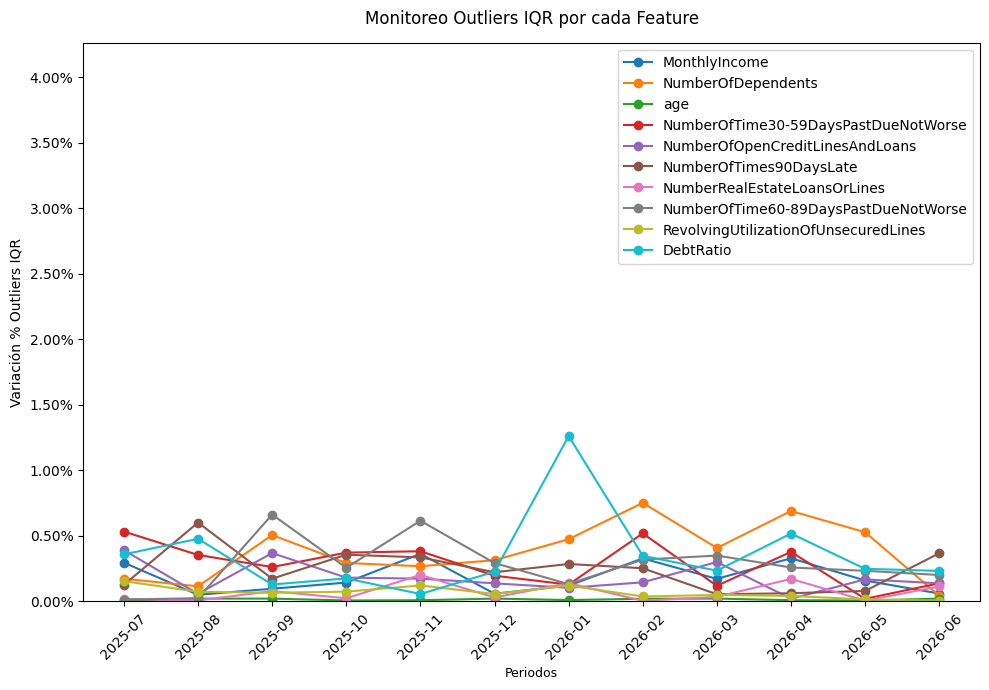

In [129]:
df_outliters, fig = monitoring_outliers_univariado(expected= df_train[FEATS_NUMERICAS], 
                               actual= df_test, 
                               period_col= 'fecha_observacion',
                               show_graph= True
                               )
display(df_outliters)
fig

iv por variable mensualizado

In [191]:
def monitor_iv_baseline_fixed(expected, actual, y_actual, period_col, show_graph = False, dict_transform = None):
    objeto_binning = Binning(
        strategy= 'frecuency',
        show_dataframe= True
    )
    objeto_binning.fit(X= expected)
    dict_rules = objeto_binning.feat_bins
    feats_train = [col for col in objeto_binning.feat_bins.keys()]
    period_list = sorted(actual[period_col].unique())
    iv_list = []
    for period in period_list:
        mask = actual[period_col] == period
        df_iv_tmp = objeto_binning.transform(
            X= actual[mask],
            y= y_actual[mask],
            operation= 'iv'
        )
        df_iv_tmp['period'] = period
        iv_list.append(df_iv_tmp)
        #print(df_iv_tmp)
        #print('==========')
    df_final = pd.concat(iv_list, axis= 0)

    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 7))
        
        for feat in feats_train:
            feat_df = df_final.loc[df_final['feature'] == feat]
            if dict_transform is not None:
                period_str = feat_df['period'].astype(str).str[-2:].map(dict_transform) + "'" + feat_df['period'].astype(str).str[2:4]
            else:
                period_str = feat_df['period'].astype(str)
            ax.plot(
                period_str,
                feat_df['iv'],
                label = feat,
                marker = 'o'
            )
        ax.set_title('Monitoreo PSI Evolutivo cada Feature', y= 1.02)
        ax.set_xlabel('Periodos', fontsize = 9)
        ax.tick_params(axis= 'x', rotation = 45)
        ax.set_ylabel('Information Value (IV)')
        ax.set_ylim(0, (df_final['iv'].max()+0.3))
        #print(feat_df['variacion_iqr'].max())
        ax.axhline(y= 0.1, linestyle = '--', color = 'tomato')
        ax.text(
            0.5, 0.10, 'PSI 0.10',
            transform=ax.get_yaxis_transform(),
            ha='center',
            va='bottom'
        )   
        ax.axhline(y = 0.3, linestyle = '--', color = 'green')
        ax.text(
            0.5, 0.30, 'PSI 0.30',
            transform=ax.get_yaxis_transform(),
            ha='center',
            va='bottom'
        )   
        #ax.yaxis.set_major_formatter(
        #    PercentFormatter(1)
        #)
        ax.legend(loc = 'upper left')
        plt.tight_layout()
        plt.close(fig)
        return df_final, fig

    return df_final

,feature,iv,period
0,RevolvingUtilizationOfUnsecuredLines,1.1538,2025-07
2,NumberOfTime30-59DaysPastDueNotWorse,0.3415,2025-07
1,age,0.2291,2025-07
3,DebtRatio,0.0914,2025-07
4,MonthlyIncome,0.0813,2025-07
...,...,...,...
5,NumberOfOpenCreditLinesAndLoans,0.0302,2026-06
9,NumberOfDependents,0.0109,2026-06
7,NumberRealEstateLoansOrLines,0.0064,2026-06
6,NumberOfTimes90DaysLate,0.0000,2026-06


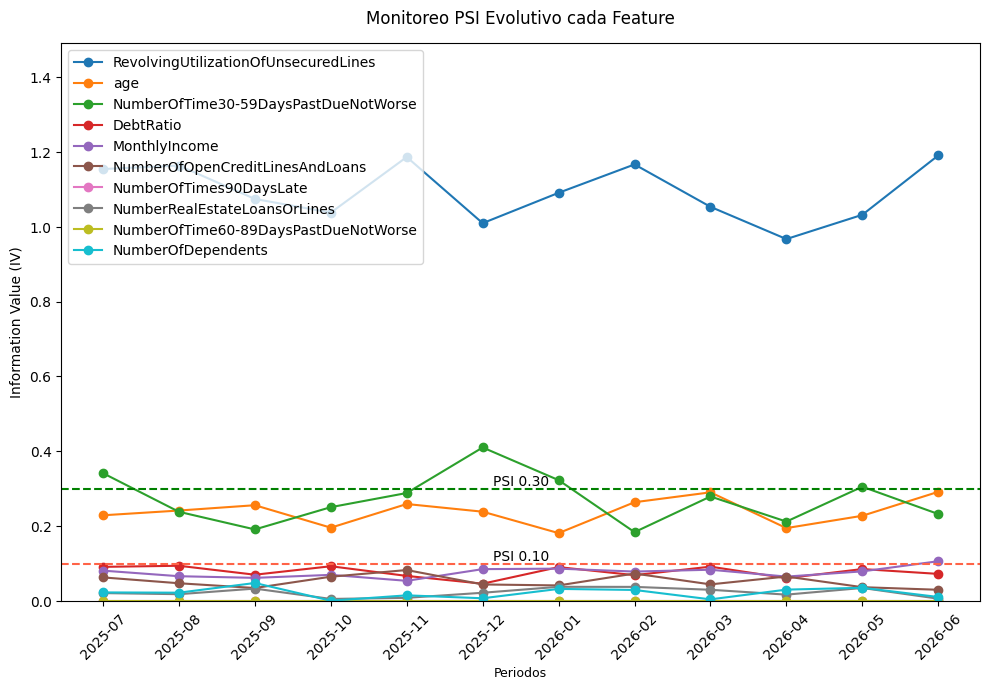

In [192]:
table, fig = monitor_iv_baseline_fixed(
    expected= df_train[FEATS_NUMERICAS],
    actual= df_test[FEATS_NUMERICAS + [PERIODO]],
    y_actual= df_test[TARGET],
    period_col= PERIODO,
    show_graph= True
)
display(table)
fig

curva roc expected vs actual

In [217]:
def threshold_f1(precision, recall):
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

def curves_roc_pr(y_true_expected, y_score_expected, y_true_actual, y_score_actual):
    precision_exp, recall_exp, thresholds_pr_exp = precision_recall_curve(y_true_expected, y_score_expected)
    fpr_exp, tpr_exp, thresholds_roc_exp = roc_curve(y_true_expected, y_score_expected)
    roc_auc_exp = roc_auc_score(y_true= y_true_expected, y_score= y_score_expected)
    gini_exp = 2 * roc_auc_exp - 1
    pr_auc_exp = average_precision_score(y_true= y_true_expected, y_score = y_score_expected)
    t_exp = np.argmax(threshold_f1(precision_exp, recall_exp))

    precision_actual, recall_actual, thresholds_pr_actual = precision_recall_curve(y_true_actual, y_score_actual)
    fpr_actual, tpr_actual, thresholds_roc_actual = roc_curve(y_true_actual, y_score_actual)
    roc_auc_actual = roc_auc_score(y_true= y_true_actual, y_score= y_score_actual)
    gini_actual = 2 * roc_auc_actual - 1
    pr_auc_actual = average_precision_score(y_true= y_true_actual, y_score = y_score_actual)
    t_actual = np.argmax(threshold_f1(precision_actual, recall_actual))

    var_exp_auc = round((((roc_auc_actual - roc_auc_exp) / roc_auc_exp)*100), 1)
    var_exp_gini = round((((gini_actual - gini_exp) / gini_exp)*100), 1)
    
    fig, ax = plt.subplots(1,2, figsize = (10,5))
    ax[0].plot(
        fpr_exp,
        tpr_exp,
        label = 'Baseline'
    )
    ax[0].plot(
        fpr_actual,
        tpr_actual,
        label = 'Test/OOT'
    )

    ax[0].set_title('Curva ROC')
    ax[0].set_ylabel('TPR')
    ax[0].set_xlabel('FPR')
    ax[0].plot([0,1],[0,1], linestyle='--', color= 'tomato')
    ax[0].text(
        0.05, 0.98,
        f'Δ ROC AUC: {var_exp_auc}% | Δ Gini: {var_exp_gini}%',
        transform = ax[0].transAxes,
        ha = 'left',
        va = 'top',
        fontsize = 9
        #fontweight = 'bold'
    )
    ax[0].legend()

    ax[1].plot(
        recall_exp,
        precision_exp,
        label = 'Baseline'
    )
    ax[1].plot(
        recall_actual,
        precision_actual,
        label = 'Test/OOT'
    )
    ax[1].set_title('Curva PR')
    ax[1].set_ylabel('Precision')
    ax[1].set_xlabel('Recall')
    ax[1].axhline(precision_actual[t_actual], color = 'red', linestyle = '--', alpha = 0.5)
    ax[1].axvline(recall_actual[t_actual], color = 'red', linestyle = '--', alpha = 0.5)
    ax[1].text(
        0.10, 0.98,
        f'PR AUC: {round(pr_auc_actual, 3)} | Best F1 Threshold: {round(thresholds_pr_actual[t_actual], 3)}',
        transform = ax[1].transAxes,
        ha = 'left',
        va = 'top',
        fontsize = 9
        #fontweight = 'bold'
    )
    ax[1].legend()
    plt.close(fig)
    
    return fig

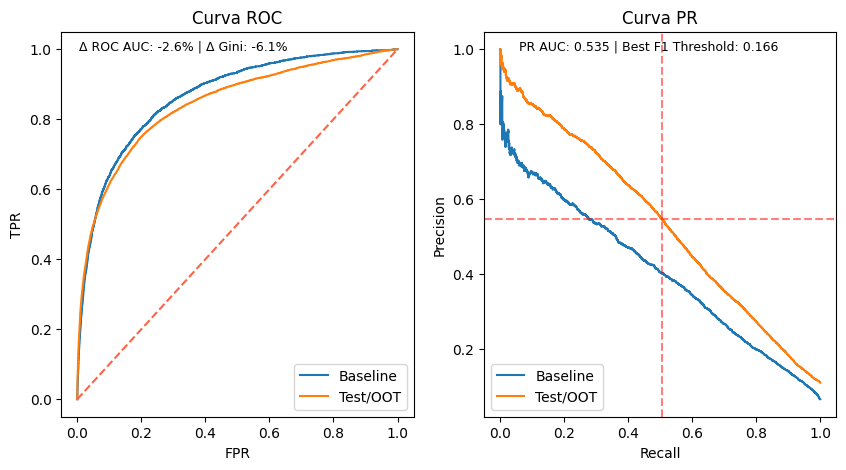

In [218]:
fig = curves_roc_pr(
    y_true_expected= df_val_economico[TARGET],
    y_score_expected= pred_proba_val,
    y_true_actual= df_test[TARGET],
    y_score_actual= pred_proba_test
)

fig

calibracion bad rate observado vs promedio

In [126]:
def monitor_bad_rate_fix_baseline(expected_y, expected_pd, actual_y, actual_pd, period_serie, show_graph= False):
    expected_y = expected_y.copy()
    actual_y = actual_y.copy()
    period_serie = period_serie.copy()

    brier_score_global = brier_score_loss(
        y_true= actual_y,
        y_proba = actual_pd
    )

    df_actual = pd.DataFrame({
        'period_actual': period_serie,
        'bad_rate': actual_y,
        'pd': actual_pd
    })
    #print(df_actual['period_actual'].dtype)
    period_list = sorted(df_actual['period_actual'].unique())
    list_actual_metrics = []

    agg = df_actual.groupby(
            'period_actual'
    ).agg(
        bad_rate = ('bad_rate', 'mean'),
        pd = ('pd', 'mean')
    ).reset_index()


    expected_target_mean = expected_y.mean()
    expected_pd_mean = expected_pd.mean()

    df_expected = pd.DataFrame(
        [{
            'period_actual': 'Baseline',
            'bad_rate': expected_target_mean,
            'pd': expected_pd_mean
        }]
    )

    df_final = pd.concat([df_expected, agg], axis = 0)
    
    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 5))
        ax.plot(
            df_final['period_actual'].astype(str),
            df_final['bad_rate'],
            color = 'blue',
            label = 'Bad Rate',
            marker = 'o'
        )
        ax.plot(
            df_final['period_actual'].astype(str),
            df_final['pd'],
            color = 'tomato',
            label = 'Probabilidad Default',
            marker = 'o'
        )
        ax.set_title(f'Monitoreo BR vs PD promedio (Brier Score Global: {brier_score_global:.4})', y= 1.02)
        ax.set_xlabel('Periodos', fontsize = 9)
        ax.tick_params(axis= 'x', rotation = 45)
        ax.set_ylabel('Ratio %')
        ax.set_ylim(0, max(df_final['bad_rate'].max() + 0.03, df_final['pd'].max() + 0.03))
        ax.yaxis.set_major_formatter(
            PercentFormatter(1)
        )
        ax.legend()
        plt.tight_layout()
        plt.close(fig)
        return df_final, fig
    return df_final



,period_actual,bad_rate,pd
0,Baseline,0.066840,0.066643
0,2025-07,0.113238,0.067138
1,2025-08,0.105996,0.068421
2,2025-09,0.112924,0.067353
3,2025-10,0.108580,0.064703
4,2025-11,0.109204,0.066868
5,2025-12,0.108754,0.065926
6,2026-01,0.116607,0.067983
7,2026-02,0.111859,0.067157
8,2026-03,0.111637,0.065454


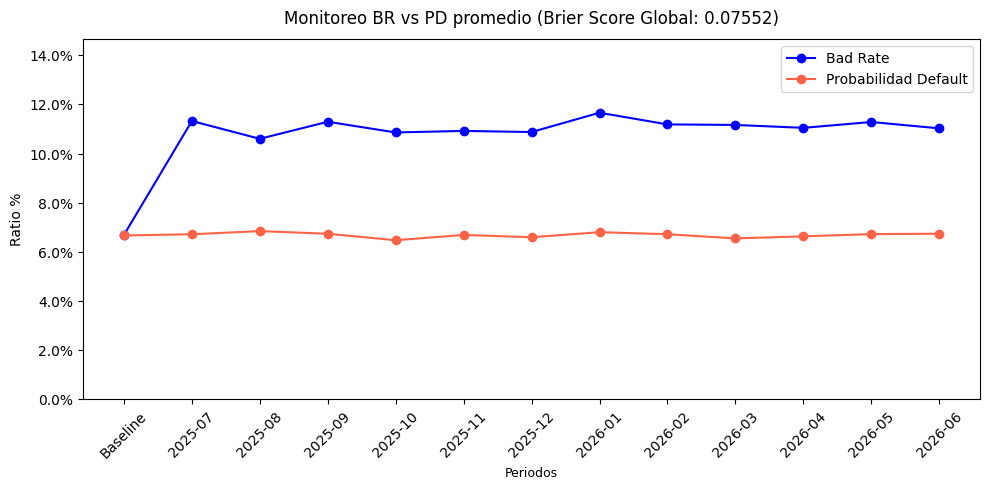

In [127]:
table, fig = monitor_bad_rate_fix_baseline(
    actual_y= df_test[TARGET],
    actual_pd= pred_proba_test,
    expected_y= df_train[TARGET],
    expected_pd= pred_proba_train,
    period_serie= df_test[PERIODO],
    show_graph= True
)
display(table)
fig

calibracion por decil en OOT (incluyendo las lineas mensuales)

In [250]:
def calibration_curve_fix_baseline(y_true_expected, y_score_expected, y_true_actual, y_score_actual, period_serie,  method_bin = 'qcut', show_curve= True):
    # crear los deciles
    df_mix_expected = pd.DataFrame({
        'y_true': y_true_expected,
        'y_score': y_score_expected
    })
    if method_bin == 'qcut':
        df_mix_expected['bins'], bins_expected = pd.qcut(
            x= df_mix_expected['y_score'],
            q= 10,
            retbins= True
        )
    elif method_bin == 'cut':
        df_mix_expected['bins'], bins_expected = pd.cut(
            x= df_mix_expected['y_score'],
            bins= 10,
            retbins= True
        )
    df_mix_actual = pd.DataFrame({
        'y_true': y_true_actual,
        'y_score': y_score_actual,
        'period': period_serie
    })
    df_mix_actual['bins'] = pd.cut(
        df_mix_actual['y_score'],
        bins= bins_expected
    )
    agg_actual = df_mix_actual.groupby(['period','bins'], observed= False).agg(
        materialidad = ('y_score', 'count'),
        y_real_mean = ('y_true', 'mean'),
        y_score_mean = ('y_score', 'mean')
    ).reset_index()

    # gráfico de curva
    period_actual = sorted(agg_actual['period'].unique())
    fig, ax = plt.subplots(1, 1, figsize = (10, 5))
    for period in period_actual:
        eje_x = agg_actual.loc[agg_actual['period'] == period, 'y_score_mean']
        eje_y = agg_actual.loc[agg_actual['period'] == period, 'y_real_mean']
        ax.plot(
            eje_x,
            eje_y,
            #marker = 'o',
            label = period
        )
    max_score = agg_actual['y_score_mean'].max()
    max_real = agg_actual['y_real_mean'].max()
    max_ambos = max(max_real, max_score)
    ax.plot(
        [0, max_ambos],
        [0, max_ambos],
        '--',
        color = 'red'
    )
    ax.set_title('Calibration Curve por decil en Test/OOT')
    ax.set_ylabel('Promedio Default Rate')
    ax.set_xlabel('Promedio PD')
    ax.legend()
    plt.close(fig)
    if show_curve:
        return agg_actual, fig
    return agg_actual


,period,bins,materialidad,y_real_mean,y_score_mean
0,2025-07,"(0.003, 0.00716]",878,0.022779,0.005970
1,2025-07,"(0.00716, 0.00953]",863,0.018540,0.008295
2,2025-07,"(0.00953, 0.0121]",946,0.019027,0.010740
3,2025-07,"(0.0121, 0.0154]",839,0.022646,0.013659
4,2025-07,"(0.0154, 0.0206]",872,0.027523,0.017770
...,...,...,...,...,...
115,2026-06,"(0.0206, 0.031]",811,0.040691,0.025423
116,2026-06,"(0.031, 0.0497]",789,0.063371,0.039441
117,2026-06,"(0.0497, 0.0823]",824,0.125000,0.064917
118,2026-06,"(0.0823, 0.168]",845,0.184615,0.114657


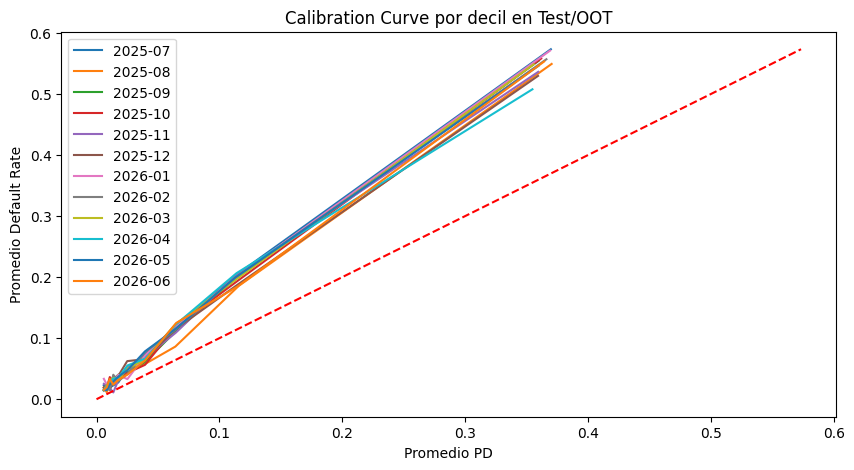

In [251]:
table, fig = calibration_curve_fix_baseline(
    y_true_expected= df_train[TARGET],
    y_score_expected= pred_proba_train,
    y_true_actual= df_test[TARGET],
    y_score_actual= pred_proba_test,
    period_serie= df_test[PERIODO],
    method_bin= 'qcut',
    show_curve= True
)
display(table)
fig

variacion de importancia del SHAP global

In [40]:
def shap_variacion_global(model, expected: pd.DataFrame, actual: pd.DataFrame, n_sample = 5000, show_graph= False, random_state = 42):
    background = expected.sample(
            n= min(n_sample, expected.shape[0]), random_state= random_state
        )
    explainer = shap.TreeExplainer(
        data= background,
        model= model,
        feature_perturbation= 'interventional',
        model_output= 'probability'
    )
    expected_sample_df = expected.sample(
        n= min(n_sample, expected.shape[0]), random_state= random_state
    )
    actual_sample_df = actual.sample(
        n= min(n_sample, expected.shape[0]), random_state= random_state
    )
    shap_values_expected = explainer(X= expected_sample_df)
    shap_values_actual = explainer(X= actual_sample_df)

    shap_matrix_actual = pd.DataFrame(
        shap_values_actual.values,
        columns= actual_sample_df.columns,
        index= actual_sample_df.index
    )

    shap_matrix_expected = pd.DataFrame(
        shap_values_expected.values,
        columns= expected_sample_df.columns,
        index= expected_sample_df.index
    )

    contributions_list_actual = []
    contributions_list_expected = []

    for feat in shap_matrix_actual.columns:
        contribution = np.abs(shap_matrix_actual[feat]).mean()
        contributions_list_actual.append({
            'feature': feat,
            'shap_value_actual': contribution
        })
    df_contributions_actual = pd.DataFrame(contributions_list_actual)

    for feat in shap_matrix_expected.columns:
        contribution = np.abs(shap_matrix_expected[feat]).mean()
        contributions_list_expected.append({
            'feature': feat,
            'shap_value_expected': contribution
        })
    df_contributions_expected = pd.DataFrame(contributions_list_expected)

    df_contribution_final = df_contributions_expected.merge(
        df_contributions_actual,
        how= 'left',
        on= 'feature'
    )
    df_contribution_final['diferencia_contribucion'] = df_contribution_final['shap_value_actual'] - df_contribution_final['shap_value_expected']
    df_contribution_final['diferencia_contribucion_abs'] = (df_contribution_final['diferencia_contribucion']).abs()
    df_contribution_final['variacion_contribucion'] = (df_contribution_final['diferencia_contribucion']) / df_contribution_final['shap_value_expected']
    df_contribution_final = df_contribution_final.sort_values(by= 'diferencia_contribucion_abs', ascending = True)
    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (10, 5))
        ax.barh(
            df_contribution_final['feature'],
            df_contribution_final['variacion_contribucion'],
            color = 'skyblue'
        )
        ax.set_title('Variación de Contribución SHAP - Expected vs Actual')
        ax.set_ylabel('Features')
        ax.set_xlabel('Variación % Contribución SHAP')
        ax.set_xlim(min(-0.2, df_contribution_final['variacion_contribucion'].min() - 0.02), df_contribution_final['variacion_contribucion'].max()+ 0.02)
        ax.xaxis.set_major_formatter(
            PercentFormatter(xmax= 1)
        )
        #ax.legend()
        plt.close(fig)
        return df_contribution_final, fig
    return df_contribution_final



In [41]:
table, fig = shap_variacion_global(
    model = model_catboost,
    expected= df_train[FEATS_NUMERICAS],
    actual= df_test[FEATS_NUMERICAS],
    n_sample= 500,
    show_graph= True,
    random_state= 42
)

 96%|=================== | 478/500 [00:11<00:00]       

,feature,shap_value_expected,shap_value_actual,diferencia_contribucion,diferencia_contribucion_abs,variacion_contribucion
4,MonthlyIncome,0.004645,0.004621,-0.000024,0.000024,-0.005258
9,NumberOfDependents,0.001361,0.001499,0.000138,0.000138,0.101462
0,RevolvingUtilizationOfUnsecuredLines,0.028097,0.028309,0.000211,0.000211,0.007526
5,NumberOfOpenCreditLinesAndLoans,0.005720,0.005361,-0.000359,0.000359,-0.062779
1,age,0.008300,0.007938,-0.000362,0.000362,-0.043614
3,DebtRatio,0.006640,0.006261,-0.000379,0.000379,-0.057056
7,NumberRealEstateLoansOrLines,0.004091,0.003535,-0.000556,0.000556,-0.135886
8,NumberOfTime60-89DaysPastDueNotWorse,0.012179,0.012901,0.000721,0.000721,0.059219
6,NumberOfTimes90DaysLate,0.021403,0.020544,-0.000859,0.000859,-0.040116
2,NumberOfTime30-59DaysPastDueNotWorse,0.015560,0.016508,0.000948,0.000948,0.060938


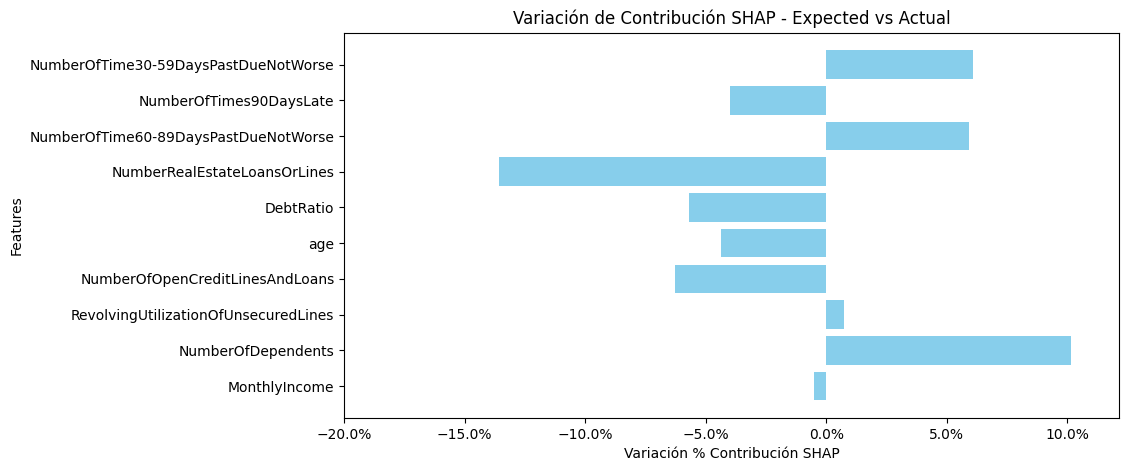

In [42]:
display(table)
fig

variacion de la importancia absoluta de shap mensualizado

In [ ]:
def shap_variacion_global_periodica(model, expected: pd.DataFrame, actual: pd.DataFrame, period_col, n_sample = 5000, show_graph= False, random_state = 42):
    background = expected.sample(
            n= min(n_sample, expected.shape[0]), random_state= random_state
        )
    explainer = shap.TreeExplainer(
        data= background,
        model= model,
        feature_perturbation= 'interventional',
        model_output= 'probability'
    )
    shap_list = []
    expected_sample_df = expected.sample(
        n= min(n_sample, expected.shape[0]), random_state= random_state
    )
    df_expected_shap = pd.DataFrame(
        explainer(X= expected_sample_df).values,
        columns= expected_sample_df.columns,
        index= expected_sample_df.index
    )

    df_agg_expected = df_expected_shap.mean()

    for feat, shap_value in df_agg_expected.items():
        shap_list.append({
            'feature': feat,
            'shap_value': shap_value,
            'period': 'Baseline'
        })

    periods_actual = sorted(actual[period_col].unique())
    feats_actual = actual.columns.tolist()
    feats_actual = [feat for feat in feats_actual if feat != period_col]

    for period in periods_actual:
        df_tmp = actual.loc[actual[period_col] == period]
        tmp_sample_df = df_tmp.sample(
            n= min(400, df_tmp.shape[0]), random_state= random_state
        )

        df_tmp_final = pd.DataFrame(
            explainer(X= tmp_sample_df[feats_actual]).values,
            columns= tmp_sample_df[feats_actual].columns,
            index= tmp_sample_df[feats_actual].index
        )

        df_agg = df_tmp_final.mean()
        for feat, shap_value in df_agg.items():
            shap_list.append({
                'feature': feat,
                'shap_value': shap_value,
                'period': period
            })
    
    df_final_agg = pd.DataFrame(shap_list)
    #print(df_final_agg)
    #print(type(df_final_agg))
    feats_final = df_final_agg['feature'].unique()
    #print(type(feats_final))

    if show_graph:
        fig, ax = plt.subplots(1, 1, figsize = (11, 6))
        for feat in feats_final:
            df_mask = df_final_agg.loc[df_final_agg['feature'] == feat]
            ax.plot(
                (df_mask['period']).astype(str),
                df_mask['shap_value'],
                label = feat
            )
        ax.set_title('Evolutivo SHAP - Test/OOT vs Baseline')
        ax.set_ylabel('SHAP Value')
        ax.set_xlabel('Periodos')
        ax.set_ylim(min(0, df_final_agg['shap_value'].min() - 0.02), df_final_agg['shap_value'].max()+ 0.02)
        ax.tick_params(axis= 'x', rotation = 45)
        #ax.xaxis.set_major_formatter(
        #    PercentFormatter(xmax= 1)
        #)
        ax.legend(
            loc = 'upper left',
            bbox_to_anchor= (1.02, 1),
            fontsize = 8.5
        )
        plt.close(fig)
        return df_final_agg, fig
    return df_final_agg



In [104]:
table, fig = shap_variacion_global_periodica(
    expected= df_train[FEATS_NUMERICAS],
    actual= df_test[FEATS_NUMERICAS + [PERIODO]],
    period_col= PERIODO,
    random_state= 42,
    n_sample= 500,
    show_graph= True
)

 96%|=================== | 480/500 [00:12<00:00]       

,feature,shap_value,period
0,RevolvingUtilizationOfUnsecuredLines,0.000187,Baseline
1,age,-0.000313,Baseline
2,NumberOfTime30-59DaysPastDueNotWorse,-0.000393,Baseline
3,DebtRatio,0.000695,Baseline
4,MonthlyIncome,0.000063,Baseline
...,...,...,...
125,NumberOfOpenCreditLinesAndLoans,0.000097,2026-06
126,NumberOfTimes90DaysLate,0.002161,2026-06
127,NumberRealEstateLoansOrLines,-0.000550,2026-06
128,NumberOfTime60-89DaysPastDueNotWorse,-0.001553,2026-06


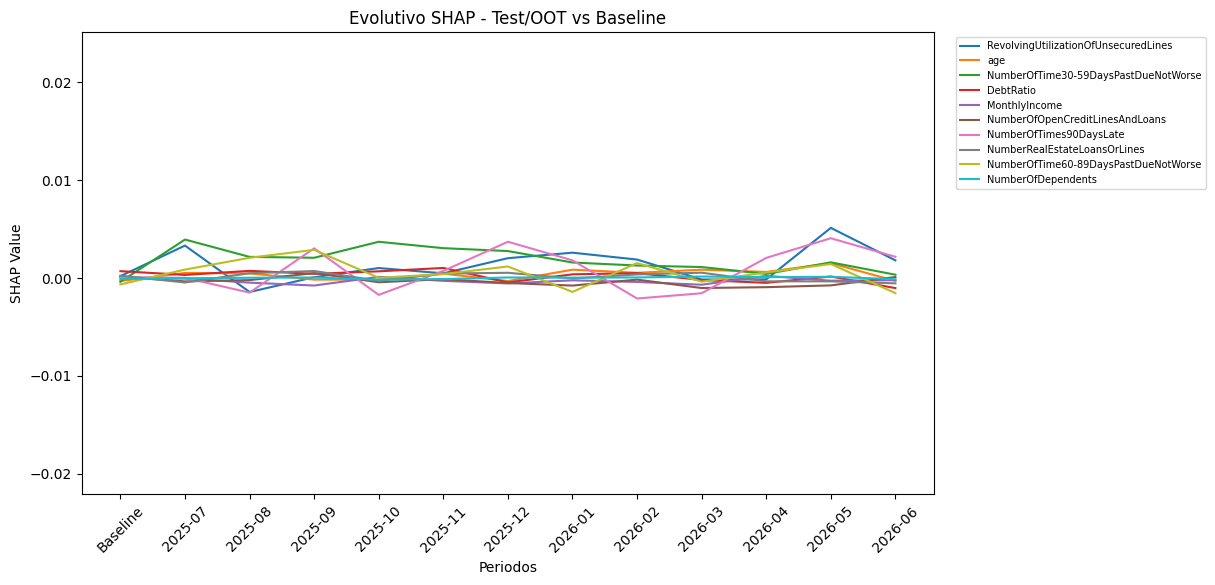

In [105]:
display(table)
fig

### Calibración por subestimación del riesgo
Utilizaremos el método de Platt Scaling

In [18]:
## Comprobando si en validación que es donde buscaremos entrenar el modelo Platt scaling
## existe la descalibración de igual forma

,bins,materialidad,y_real_mean,y_score_mean,dif_nom,dif_var_%
0,"(0.002, 0.00711]",4500,0.003778,0.005937,-0.002159,-36.36
1,"(0.00711, 0.00946]",4500,0.005778,0.008258,-0.002480,-30.04
2,"(0.00946, 0.0121]",4500,0.008000,0.010737,-0.002737,-25.49
3,"(0.0121, 0.0154]",4500,0.014000,0.013667,0.000333,2.44
4,"(0.0154, 0.0207]",4500,0.017333,0.017812,-0.000479,-2.69
5,"(0.0207, 0.031]",4500,0.026444,0.025314,0.001131,4.47
6,"(0.031, 0.0496]",4500,0.039111,0.039612,-0.000500,-1.26
7,"(0.0496, 0.0816]",4500,0.065778,0.064199,0.001578,2.46
8,"(0.0816, 0.167]",4500,0.115333,0.113148,0.002185,1.93
9,"(0.167, 0.951]",4500,0.372889,0.364468,0.008421,2.31


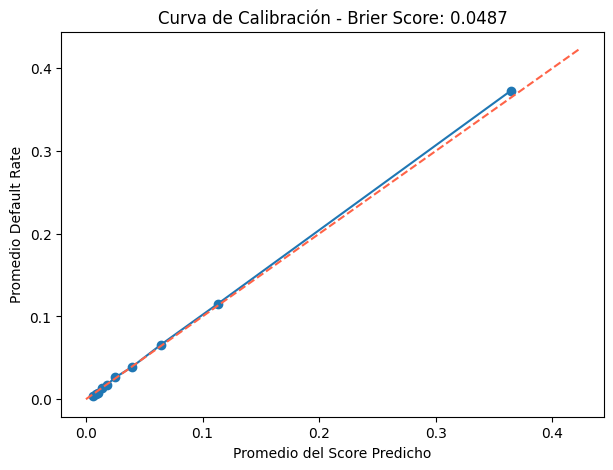

In [8]:
df_val_calibration, fig = calibration_curve(
    y_true= df_val_economico[TARGET],
    y_score= pred_proba_val,
    method_bin= 'qcut',
    show_curve= True
)
display(df_val_calibration)
fig

En validación se observa bastante calibrado el modelo, entonces buscaremos entrenar el Platt Scaling con una parte del dataset de test (primeros 6 meses)

In [9]:
def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def calibracion_platt_scaling(score_raw_expected, y_true_expected, score_raw_actual, y_true_actual, show_graph= False, show_coef = False):
    score_logit_expected = logit(p = score_raw_expected)
    score_logit_actual = logit(p = score_raw_actual)
    brier_score_actual_pre_calibrado = brier_score_loss(
        y_true= y_true_actual,
        y_proba = score_raw_actual
    )
    platt_model = LogisticRegression()
    platt_model.fit(score_logit_expected.reshape(-1, 1), y_true_expected)

    dict_detalles = {
        'coeficientes': platt_model.coef_,
        'intercepto': platt_model.intercept_
    }

    pd_calibrada_actual = platt_model.predict_proba(score_logit_actual.reshape(-1, 1))[:, 1]

    brier_score_calibrado_actual = brier_score_loss(
        y_true= y_true_actual,
        y_proba= pd_calibrada_actual
    )
    dict_detalles['brier_score'] = {
        'brier_score_pre_calibrado': brier_score_actual_pre_calibrado,
        'brier_score_calibrado': brier_score_calibrado_actual
    }

    df_calibration, fig = calibration_curve(y_true= y_true_actual, y_score= pd_calibrada_actual, method_bin= 'qcut', show_curve= True)
    if show_graph:
        if show_coef:
            return df_calibration, fig, dict_detalles
        else:
            return df_calibration, fig
    if show_coef:
        return df_calibration, dict_detalles
    return df_calibration


In [13]:
df_test_6_primeros_meses = df_test.loc[df_test[PERIODO] <= '2025-12']
df_test_6_ultimos_meses = df_test.loc[df_test[PERIODO] > '2025-12']
print(f'Primeros 6 meses -> Max: {max(df_test_6_primeros_meses[PERIODO])}, Min: {min(df_test_6_primeros_meses[PERIODO])}')
print(f'Ultimos 6 meses -> Max: {max(df_test_6_ultimos_meses[PERIODO])}, Min: {min(df_test_6_ultimos_meses[PERIODO])}')

Primeros 6 meses -> Max: 2025-12, Min: 2025-07
Ultimos 6 meses -> Max: 2026-06, Min: 2026-01


In [26]:
df_calibration, fig, dict_coef = calibracion_platt_scaling(
    score_raw_expected= pred_proba_test[df_test_6_primeros_meses.index],
    y_true_expected= df_test_6_primeros_meses[TARGET],
    score_raw_actual= pred_proba_test[df_test_6_ultimos_meses.index],
    y_true_actual= df_test_6_ultimos_meses[TARGET],
    show_coef= True,
    show_graph= True
)

,bins,materialidad,y_real_mean,y_score_mean,dif_nom,dif_var_%
0,"(0.00469, 0.0132]",5045,0.018236,0.010957,0.007279,66.43
1,"(0.0132, 0.0177]",5044,0.020619,0.015385,0.005234,34.02
2,"(0.0177, 0.0227]",5044,0.026170,0.020110,0.006059,30.13
3,"(0.0227, 0.0289]",5044,0.031523,0.025629,0.005894,23.00
4,"(0.0289, 0.039]",5044,0.033703,0.033344,0.000359,1.08
5,"(0.039, 0.0597]",5044,0.045400,0.048077,-0.002677,-5.57
6,"(0.0597, 0.0957]",5044,0.070777,0.076287,-0.005510,-7.22
7,"(0.0957, 0.157]",5044,0.121729,0.123480,-0.001752,-1.42
8,"(0.157, 0.305]",5044,0.200238,0.212325,-0.012087,-5.69
9,"(0.305, 0.973]",5044,0.554718,0.535418,0.019300,3.60


{'coeficientes': array([[1.03470064]]),
 'intercepto': array([0.79450398]),
 'brier_score': {'brier_score_pre_calibrado': 0.07633563527386862,
  'brier_score_calibrado': 0.07146166717743958}}

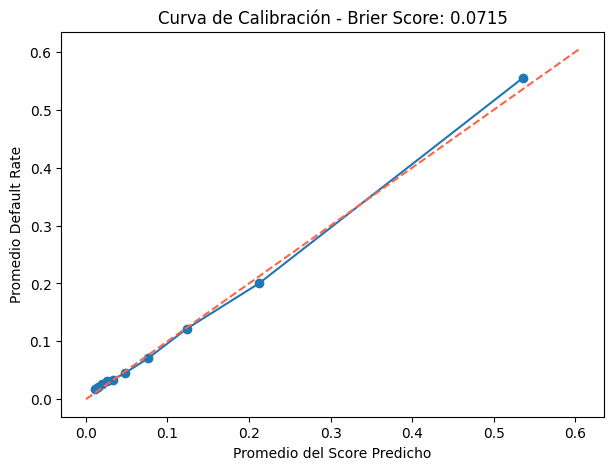

In [27]:
display(df_calibration)
display(dict_coef)
fig

In [ ]:
def rho_basel_retail_other(pd):
    """Correlación de activos, fórmula Basel II para 'other retail' exposures"""
    term = (1 - np.exp(-35 * pd)) / (1 - np.exp(-35))
    return 0.03 * term + 0.16 * (1 - term)

def vasicek_quantile(pd, rho, alpha):
    """
    pd:    PD esperada (ej. 0.05)
    rho:   correlación de activos (0 a 1)
    alpha: nivel de confianza (ej. 0.999 para WCDR Basel, 0.975 para límite sup. de un IC 95%)
    """
    return norm.cdf(
        (norm.ppf(pd) + np.sqrt(rho) * norm.ppf(alpha)) / np.sqrt(1 - rho)
    )

def vasicek_interval(pd, rho, confidence=0.95):
    """
    Intervalo de confianza bilateral para la tasa de default observada, dado PD y rho.
    Devuelve (limite_inferior, limite_superior)
    """
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    lower = vasicek_quantile(pd, rho, alpha_lower)
    upper = vasicek_quantile(pd, rho, alpha_upper)
    return lower, upper

def intervalos_vasicek(df_calibration, confidence=0.95, figsize=(9, 6)):
    """
    df_calibration: tu tabla con y_score_mean (PD esperada) y y_real_mean (default observado) por bin
    """
    df = df_calibration.copy().sort_values('y_score_mean').reset_index(drop=True)
    
    # calcular rho y bandas por bin
    df['rho'] = df['y_score_mean'].apply(rho_basel_retail_other)
    bounds = df.apply(
        lambda row: vasicek_interval(row['y_score_mean'], row['rho'], confidence),
        axis=1
    )
    df['ic_inferior'] = bounds.apply(lambda x: x[0])
    df['ic_superior'] = bounds.apply(lambda x: x[1])
    df['fuera_de_rango'] = (df['y_real_mean'] < df['ic_inferior']) | (df['y_real_mean'] > df['ic_superior'])

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(df))  # eje x = índice de bin (más limpio que valores continuos)

    # banda de confianza Vasicek
    ax.fill_between(
        x, df['ic_inferior'], df['ic_superior'],
        color='steelblue', alpha=0.2,
        label=f'Intervalo Vasicek ({int(confidence*100)}%)'
    )
    ax.plot(x, df['ic_inferior'], color='steelblue', linestyle='--', linewidth=1)
    ax.plot(x, df['ic_superior'], color='steelblue', linestyle='--', linewidth=1)

    # PD esperada (línea central del modelo)
    ax.plot(x, df['y_score_mean'], color='steelblue', linewidth=1.5,
            label='PD esperada (score)')

    # default rate observado, resaltando los que caen fuera de rango
    colors = np.where(df['fuera_de_rango'], 'red', 'black')
    ax.scatter(x, df['y_real_mean'], color=colors, zorder=5, s=50,
               label='Default rate observado')
    ax.plot(x, df['y_real_mean'], color='gray', linewidth=1, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(df['bins'].astype(str), rotation=45, ha='right')
    ax.set_xlabel('Bin (decil de score)')
    ax.set_ylabel('Tasa de default')
    ax.set_title('Backtesting de calibración con intervalos de Vasicek')
    ax.legend()
    plt.tight_layout()
    plt.close(fig)

    return df, fig

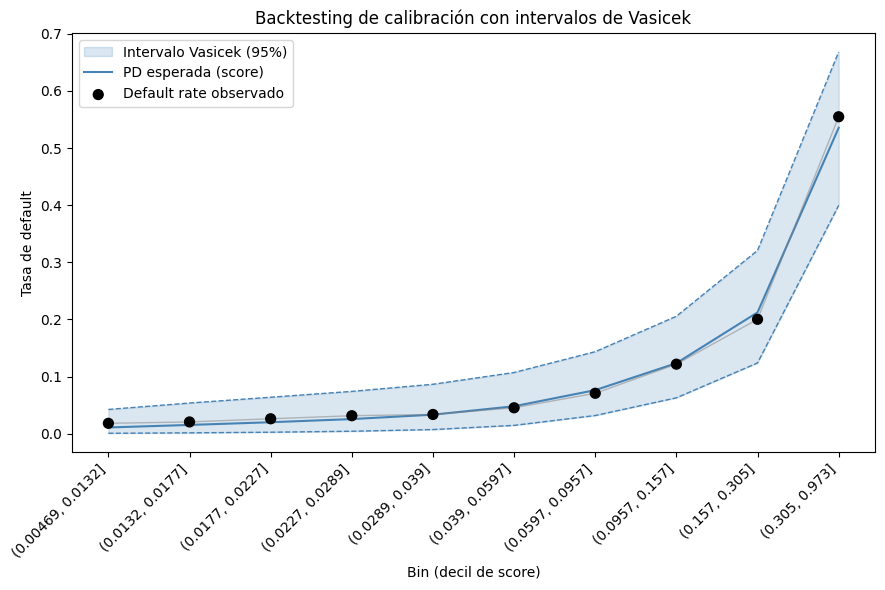

In [38]:
df_vasicek, fig = intervalos_vasicek(df_calibration, confidence=0.95)
fig

In [35]:
df_vasicek

,bins,materialidad,y_real_mean,y_score_mean,dif_nom,dif_var_%,rho,ic_inferior,ic_superior,fuera_de_rango
0,"(0.00469, 0.0132]",5045,0.018236,0.010957,0.007279,66.43,0.118592,0.000789,0.042512,False
1,"(0.0132, 0.0177]",5044,0.020619,0.015385,0.005234,34.02,0.105874,0.001544,0.053708,False
2,"(0.0177, 0.0227]",5044,0.026170,0.020110,0.006059,30.13,0.094307,0.002651,0.063857,False
3,"(0.0227, 0.0289]",5044,0.031523,0.025629,0.005894,23.00,0.083013,0.004328,0.074098,False
4,"(0.0289, 0.039]",5044,0.033703,0.033344,0.000359,1.08,0.070467,0.007310,0.086542,False
5,"(0.039, 0.0597]",5044,0.045400,0.048077,-0.002677,-5.57,0.054163,0.014637,0.107165,False
6,"(0.0597, 0.0957]",5044,0.070777,0.076287,-0.005510,-7.22,0.039002,0.031863,0.143577,False
7,"(0.0957, 0.157]",5044,0.121729,0.123480,-0.001752,-1.42,0.031726,0.062841,0.205595,False
8,"(0.157, 0.305]",5044,0.200238,0.212325,-0.012087,-5.69,0.030077,0.123880,0.320778,False
9,"(0.305, 0.973]",5044,0.554718,0.535418,0.019300,3.60,0.030000,0.399584,0.668199,False


In [43]:
model_catboost.feature_names_

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [44]:
df_test.dtypes

fecha_observacion                       period[M]
RevolvingUtilizationOfUnsecuredLines      float64
age                                         int64
NumberOfTime30-59DaysPastDueNotWorse        int64
DebtRatio                                 float64
MonthlyIncome                             float64
NumberOfOpenCreditLinesAndLoans             int64
NumberOfTimes90DaysLate                     int64
NumberRealEstateLoansOrLines                int64
NumberOfTime60-89DaysPastDueNotWorse        int64
NumberOfDependents                        float64
saldo_actual                              float64
clasificacion_sbs                          object
Garantia                                  float64
y_score_modelo                            float64
SeriousDlqin2yrs                            int64
fecha_observacion_str                      object
dtype: object